# Implied Volatilty and the Volatility Smile

This notebook will:

- Introduce implied volatility and how it relates market prices to model prices  
- Demonstrate the `implied_vol` method of the `BlackScholes` class on a single option  
- Visualize how option price changes with volatility  
- Build a synthetic volatility smile by computing implied volatilities across strikes  

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from options_pricing.models.black_scholes import BlackScholes

## Single-Option Implied Volatility Demo

Start with a single European call option:

- Spot price: $ S = 100 $
- Strike: $ K = 100 $
- Risk-free rate: $ r = 2\% $
- Time to maturity: $ T = 1 $ year  
- "True" volatility: $ \sigma_{\text{true}} = 0.25 $

The model is used to generate a market price, then we try to recover the volatility using the `implied_vol` method.

In [2]:
# Define parameters for single option
S = 100
K = 100
r = 0.02
T = 1.0
true_sigma = 0.25

# Generate market price using the true volatility
bs_true = BlackScholes(S, K, r, T, true_sigma)
market_price = bs_true.call_price()
market_price

np.float64(10.870558490557599)

In [3]:
# Recover implied volatility from the market price
bs_iv = BlackScholes(S, K, r, T, sigma=0.2)  # initial guess for sigma
implied_sigma = bs_iv.implied_vol(market_price, option_type="call")

# Compare true vs implied volatility
print("True sigma: ", true_sigma)
print("Implied sigma: ", implied_sigma)

True sigma:  0.25
Implied sigma:  0.2500000000000002


## Price as a Function of Volatility

To build intuition, all parameters are fixed except volatility to see how the call price changes as a function of $ \sigma $.

The point where the horizontal line (market price) intersects the curve corresponds to the implied volatility that was solved for earlier.


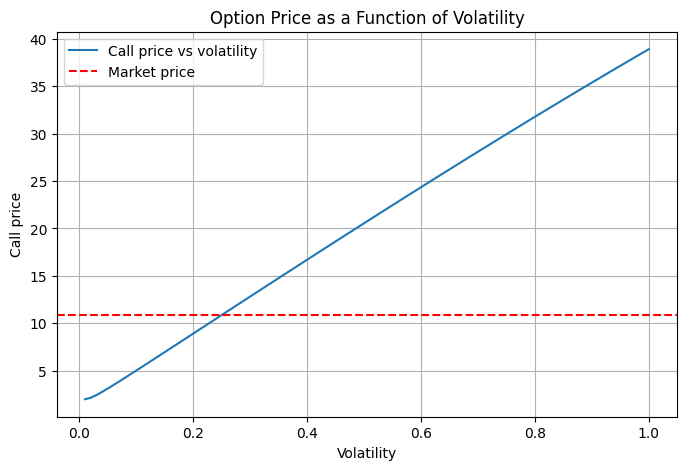

In [4]:
# Compute prices across a range of volatilities
sigmas = np.linspace(0.01, 1.0, 100)
prices = [bs_iv.price_with_sigma(sigma) for sigma in sigmas]

# Plot price vs volatility
plt.figure(figsize=(8, 5))
plt.plot(sigmas, prices, label="Call price vs volatility")
plt.axhline(market_price, color="red", linestyle="--", label="Market price")
plt.xlabel("Volatility")
plt.ylabel("Call price")
plt.title("Option Price as a Function of Volatility")
plt.grid(True)
plt.legend()
plt.show()

## Volatility Smile

The volatility smile shows how implied volatility varies across different strike prices.

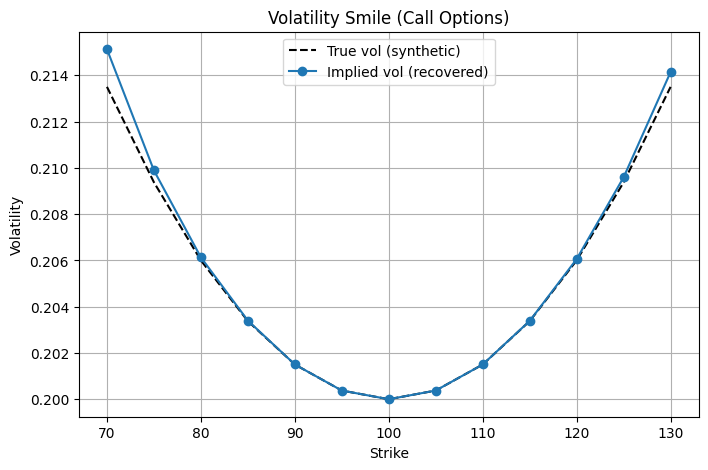

In [5]:
# Define a range of strikes
strikes = np.linspace(70, 130, 13)

# Define a synthetic "true" volatility smile
def true_vol(K, S=100):
    m = K / S  # moneyness
    # Simple convex smile around ATM
    return 0.2 + 0.15 * (m - 1.0)**2

true_vols = np.array([true_vol(K, S) for K in strikes])

# Generate synthetic market prices using the true smile
market_prices_smile = []
for K_i, sigma_i in zip(strikes, true_vols):
    bs = BlackScholes(S, K_i, r, T, sigma_i)
    market_prices_smile.append(bs.call_price())

market_prices_smile = np.array(market_prices_smile)

# Recover implied volatilities from the synthetic market prices
implied_vols = []
for K_i, price_i in zip(strikes, market_prices_smile):
    bs = BlackScholes(S, K_i, r, T, sigma=0.2)  # initial guess
    iv_i = bs.implied_vol(price_i, option_type="call")
    implied_vols.append(iv_i)

implied_vols = np.array(implied_vols)

# Plot the volatility smile - true vs implied
plt.figure(figsize=(8, 5))
plt.plot(strikes, true_vols, "k--", label="True vol (synthetic)")
plt.plot(strikes, implied_vols, "o-", label="Implied vol (recovered)")
plt.xlabel("Strike")
plt.ylabel("Volatility")
plt.title("Volatility Smile (Call Options)")
plt.grid(True)
plt.legend()
plt.show()